# Метрические алгоритмы

В практической части проекта тебе предстоит научиться различать виды 
пингвинов по их морфологическим характеристикам. В этом тебе поможет метод 
ближайших соседей (k-NN), который будет классифицировать пингвинов на основе 
сходства их признаков с уже известными примерами.

![Описание признаков пингвинов](../../production/AI_Machine_Learning.Project_2.ID_1577772/misc/images/penguin.png)

## Задание 1. Загрузка данных

В этом задании ты будешь работать с датасетом Palmer Penguins. Этот датасет 
содержит измерения различных характеристик пингвинов трёх видов: Adélie, 
Chinstrap и Gentoo. Подробное описание датасета можно найти на 
[официальном сайте](https://allisonhorst.github.io/palmerpenguins/).

Данные включают в себя морфологические измерения пингвинов: длину и глубину 
клюва (culmen), длину ласт (flipper), массу тела и другие характеристики. 
Эти измерения позволяют различать виды пингвинов, что делает датасет 
отличным примером для изучения метрических алгоритмов классификации.

Давай познакомимся с данными и шаг за шагом разберёмся, как с ними работать:

1. **Загрузка данных:**
   - Загрузи датасет из файла `datasets/penguins_size.csv`.
   - Выведи размерность датасета.

2. **Разведочный анализ данных (EDA):**
   - Изучи, какие признаки (столбцы) присутствуют в датасете.
   - Удали строки, в которых отсутствует хотя бы одно значение.
   - Определи, какой столбец является целевой переменной (Y) для задачи 
   классификации, а какие столбцы будут использоваться в качестве 
   признаков (X).

3. **Разделение данных:**
   - Раздели датасет на обучающую (train) и тестовую (test) выборки в 
   соотношении 70% к 30% соответственно.
   - Используй `random_state=42` для воспроизводимости результатов.
   - Выведи размеры обеих выборок.

4. **Визуализация признаков:**
   - Построй график рассеяния (scatter plot), на котором будут отображены 
   обе выборки — обучающая и тестовая — на одном графике.
   - Для визуализации используй два признака из набора данных: 
   длину клюва (ось X) и длину ласт (ось Y).
   - Для обучающей выборки (train): точки должны быть окрашены в разные 
   цвета в соответствии с классами (видами пингвинов). Используй легенду, 
   чтобы показать соответствие цветов классам.
   - Для тестовой выборки (test): все точки должны быть серого цвета, чтобы 
   визуально показать, что их классы нам неизвестны (именно их мы будем 
   предсказывать с помощью алгоритма k-NN).
   - Добавь подписи осей и заголовок графика.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Настройка для отображения графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
data = pd.read_csv("../../production/AI_Machine_Learning.Project_2.ID_1577772/datasets/penguins_size.csv")

In [3]:
print(f"Размерность датасета: {data.shape}")

Размерность датасета: (344, 7)


In [4]:
data.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
numeric_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

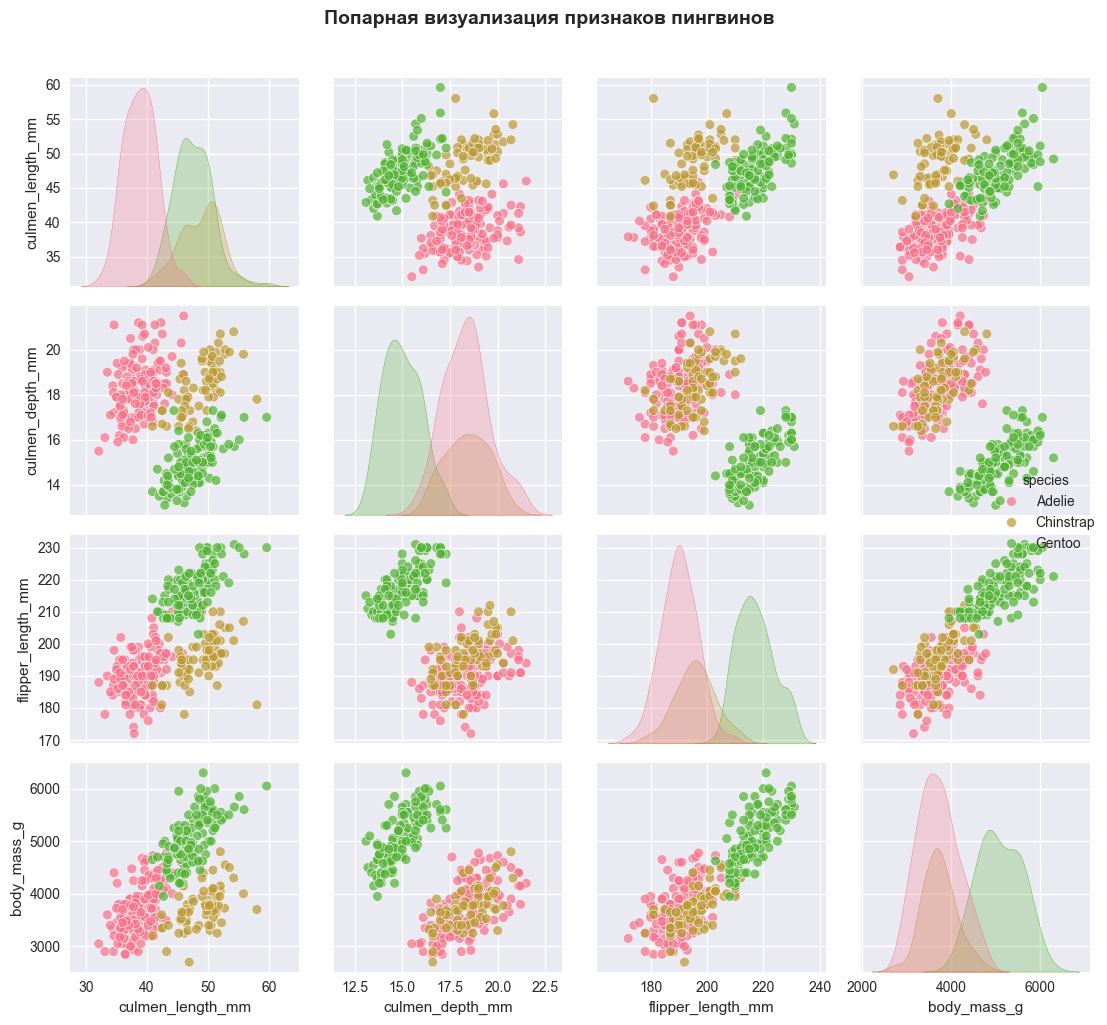

In [6]:
sns.pairplot(
    data.dropna(),  # Используем данные без пропущенных значений
    vars=numeric_columns,
    hue='species',  # Раскраска по видам пингвинов
    diag_kind='kde',  # Диагональные графики - плотность распределения
    plot_kws={'alpha': 0.7, 's': 50},  # Параметры для scatter plots
    height=2.5  # Высота каждого subplot
)

plt.suptitle('Попарная визуализация признаков пингвинов', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
data = data.dropna()

In [8]:
y = data['species']
feature_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = data[feature_columns]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42,
    stratify=y  # Сохраняем пропорции классов в обеих выборках
)

print(f"Размер обучающей выборки (X_train): {X_train.shape}")
print(f"Размер тестовой выборки (X_test): {X_test.shape}")
print(f"Размер обучающей выборки (y_train): {y_train.shape}")
print(f"Размер тестовой выборки (y_test): {y_test.shape}")

Размер обучающей выборки (X_train): (233, 4)
Размер тестовой выборки (X_test): (101, 4)
Размер обучающей выборки (y_train): (233,)
Размер тестовой выборки (y_test): (101,)


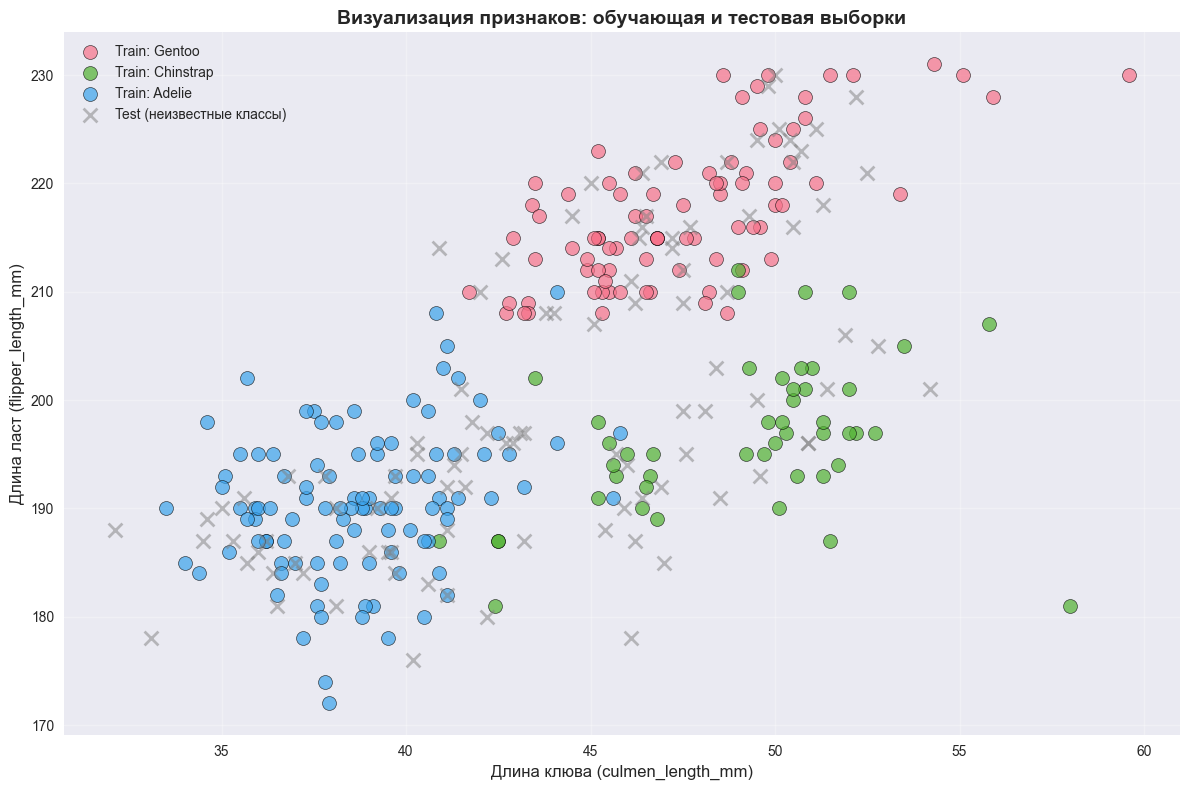

In [10]:
plt.figure(figsize=(12, 8))

# Получаем уникальные классы для цветовой схемы
unique_classes = y_train.unique()
colors = sns.color_palette("husl", len(unique_classes))
class_color_map = dict(zip(unique_classes, colors))

# Визуализация обучающей выборки (цветные точки по классам)
for species in unique_classes:
    mask = y_train == species
    plt.scatter(
        X_train[mask]['culmen_length_mm'], 
        X_train[mask]['flipper_length_mm'],
        c=[class_color_map[species]], 
        label=f'Train: {species}',
        alpha=0.7,
        s=100,
        edgecolors='black',
        linewidth=0.5
    )

# Визуализация тестовой выборки (серые точки)
plt.scatter(
    X_test['culmen_length_mm'], 
    X_test['flipper_length_mm'],
    c='gray', 
    label='Test (неизвестные классы)',
    alpha=0.5,
    s=100,
    marker='x',
    linewidth=2
)

plt.xlabel('Длина клюва (culmen_length_mm)', fontsize=12)
plt.ylabel('Длина ласт (flipper_length_mm)', fontsize=12)
plt.title('Визуализация признаков: обучающая и тестовая выборки', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Задание 2. Метрики

На построенном графике рассеяния ты видишь 3 больших кластера в пространстве признаков длины клюва и длины ласт. Каждый кластер соответствует одному из видов пингвинов. Теперь для серых точек (тестовой выборки) нужно найти ближайшие точки из обучающей выборки, чтобы понять, к какому классу их отнести.

Для определения функции расстояния между точками в пространстве признаков существуют различные метрики. В этом задании ты реализуешь несколько основных метрик расстояния, которые используются в метрических алгоритмах.

### 1. Реализация метрики Минковского

Метрика Минковского — это обобщенная метрика расстояния, которая включает в себя множество других метрик как частные случаи.

Формула метрики Минковского для двух точек $p = (p_1, p_2, ..., p_n)$ и $q = (q_1, q_2, ..., q_n)$:

$$d(p, q) = \left(\sum_{i=1}^{n} |p_i - q_i|^p\right)^{1/p}$$

где $p$ — параметр метрики (не путай с точкой $p$).


In [11]:
def minkowski_distance(point1, point2, p):
    """
    Вычисляет расстояние Минковского между двумя точками.
    
    Параметры:
    -----------
    point1 : array-like
        Первая точка (массив или список координат)
    point2 : array-like
        Вторая точка (массив или список координат)
    p : float
        Параметр метрики Минковского
        
    Возвращает:
    -----------
    float
        Расстояние Минковского между точками
    """
    point1 = np.array(point1)
    point2 = np.array(point2)
    
    if len(point1) != len(point2):
        raise ValueError("Точки должны иметь одинаковую размерность")
    
    differences = np.abs(point1 - point2)
    sum_powered = np.sum(differences ** p)
    distance = sum_powered ** (1 / p)
    
    return distance

2. **Реализуй евклидову и манхэттенскую метрики:**
   - Евклидова метрика — это частный случай метрики Минковского при $p = 2$.
   Это стандартное расстояние между точками в евклидовом пространстве, 
   которое ты изучал в геометрии.
   - Манхэттенская метрика (также известная как метрика L1 или 
   "city block distance") — это частный случай метрики Минковского при 
   $p = 1$. Название происходит от того, что это расстояние, которое нужно 
   пройти по улицам прямоугольной сетки (как в Манхэттене), где можно 
   двигаться только горизонтально и вертикально.
   - Реализуй функции `euclidean_distance(point1, point2)` и 
   `manhattan_distance(point1, point2)`, используя реализованную ранее 
   метрику Минковского.

In [12]:
def euclidean_distance(point1, point2):
    """
    Вычисляет евклидово расстояние между двумя точками.
    Использует метрику Минковского с p=2.
    
    Параметры:
    -----------
    point1 : array-like
        Первая точка (массив или список координат)
    point2 : array-like
        Вторая точка (массив или список координат)
        
    Возвращает:
    -----------
    float
        Евклидово расстояние между точками
    """
    return minkowski_distance(point1, point2, p=2)


In [13]:
def manhattan_distance(point1, point2):
    """
    Вычисляет манхэттенское расстояние между двумя точками.
    Использует метрику Минковского с p=1.
    
    Параметры:
    -----------
    point1 : array-like
        Первая точка (массив или список координат)
    point2 : array-like
        Вторая точка (массив или список координат)
        
    Возвращает:
    -----------
    float
        Манхэттенское расстояние между точками
    """
    return minkowski_distance(point1, point2, p=1)

3. **Расчет расстояния:**
   - Для точки из тестовой выборки с минимальным `culmen_length_mm` 
   рассчитай манхэттенское расстояние от точки (45, 200).
   - Для точки из тестовой выборки с максимальным `flipper_length_mm` 
   рассчитай евклидово расстояние от точки (45, 200).
   - Визуализируй только эти точки и точку (45, 200). 

In [14]:
# Находим точку с минимальным culmen_length_mm в тестовой выборке
min_culmen_idx = X_test["culmen_length_mm"].idxmin()
min_culmen_point = X_test.loc[min_culmen_idx, ["culmen_length_mm", "flipper_length_mm"]].values
min_culmen_point

array([ 32.1, 188. ])

In [15]:
# Находим точку с максимальным flipper_length_mm в тестовой выборке
max_flipper_idx = X_test["flipper_length_mm"].idxmax()
max_flipper_point = X_test.loc[max_flipper_idx, ["culmen_length_mm", "flipper_length_mm"]].values
max_flipper_point

array([ 50., 230.])

In [16]:
# Точка отсчета
reference_point = np.array([45, 200])

In [17]:
# Рассчитываем расстояния
print("\nРасстояния от точки (45, 200):")
print(f"\nТочка с минимальным culmen_length_mm:")
print(f"  Манхэттенское расстояние: {manhattan_distance(min_culmen_point, reference_point):.2f}")

print(f"\nТочка с максимальным flipper_length_mm:")
print(f"  Евклидово расстояние: {euclidean_distance(max_flipper_point, reference_point):.2f}")


Расстояния от точки (45, 200):

Точка с минимальным culmen_length_mm:
  Манхэттенское расстояние: 24.90

Точка с максимальным flipper_length_mm:
  Евклидово расстояние: 30.41


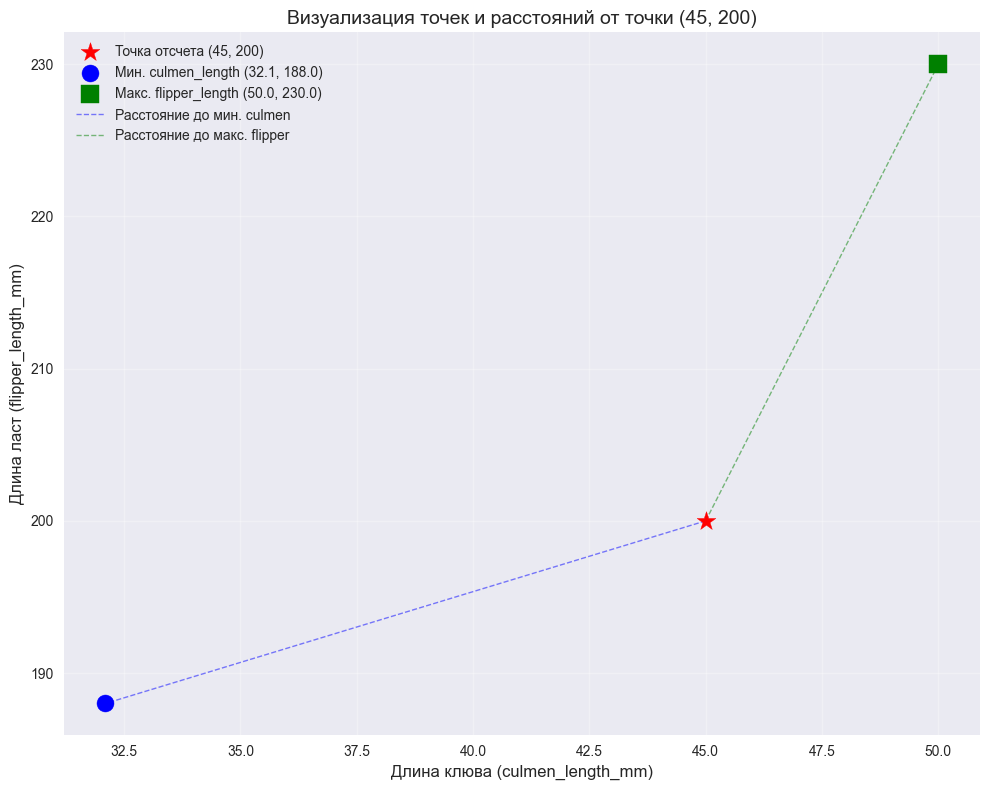

In [18]:
# Визуализация
plt.figure(figsize=(10, 8))

# Точка отсчета
plt.scatter(reference_point[0], reference_point[1], 
           color="red", s=200, marker="*", 
           label="Точка отсчета (45, 200)", zorder=5)

# Точка с минимальным culmen_length_mm
plt.scatter(min_culmen_point[0], min_culmen_point[1], 
           color="blue", s=150, marker="o", 
           label=f"Мин. culmen_length ({min_culmen_point[0]:.1f}, {min_culmen_point[1]:.1f})", 
           zorder=4)

# Точка с максимальным flipper_length_mm
plt.scatter(max_flipper_point[0], max_flipper_point[1], 
           color="green", s=150, marker="s", 
           label=f"Макс. flipper_length ({max_flipper_point[0]:.1f}, {max_flipper_point[1]:.1f})", 
           zorder=4)

# Соединяем линии для визуализации расстояний
plt.plot([reference_point[0], min_culmen_point[0]], 
         [reference_point[1], min_culmen_point[1]], 
         "b--", alpha=0.5, linewidth=1, label="Расстояние до мин. culmen")
plt.plot([reference_point[0], max_flipper_point[0]], 
         [reference_point[1], max_flipper_point[1]], 
         "g--", alpha=0.5, linewidth=1, label="Расстояние до макс. flipper")

plt.xlabel("Длина клюва (culmen_length_mm)", fontsize=12)
plt.ylabel("Длина ласт (flipper_length_mm)", fontsize=12)
plt.title("Визуализация точек и расстояний от точки (45, 200)", fontsize=14)
plt.legend(loc="best", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Задание 3. Ближайшие соседи

В этом задании ты реализуешь алгоритм 1-NN (k=1), где для каждой точки из 
тестовой выборки находится ближайший сосед из обучающей выборки, и класс 
этого соседа присваивается тестовой точке.

### 1. Реализация поиска ближайшего соседа


In [19]:
def find_nearest_neighbor(test_point, train_data, train_labels, distance_func):
    """
    Находит ближайшего соседа для тестовой точки из обучающей выборки.
    
    Параметры:
    -----------
    test_point : array-like
        Точка из тестовой выборки (массив признаков)
    train_data : array-like или DataFrame
        Обучающая выборка (массив или DataFrame с признаками)
    train_labels : array-like
        Метки классов для обучающей выборки
    distance_func : function
        Функция для вычисления расстояния (например, euclidean_distance)
        
    Возвращает:
    -----------
    label
        Метка класса ближайшего соседа
    """
    test_point = np.array(test_point)
    train_data = np.array(train_data)
    
    min_distance = float("inf")
    nearest_neighbor_idx = None
    
    # Проходим по всем точкам обучающей выборки
    for i, train_point in enumerate(train_data):
        distance = distance_func(test_point, train_point)
        if distance < min_distance:
            min_distance = distance
            nearest_neighbor_idx = i
    
    # Возвращаем метку класса ближайшего соседа
    return train_labels[nearest_neighbor_idx]

### 2. Классификация тестовой выборки


In [20]:
X_train_2d_array = X_train[["flipper_length_mm", "culmen_length_mm"]].values
X_test_2d_array = X_test[["flipper_length_mm", "culmen_length_mm"]].values
y_train_2d_array = y_train.values
y_test_2d_array = y_test.values

# Предсказания для каждой точки тестовой выборки
predictions = []

for test_point in X_test_2d_array:
    predicted_label = find_nearest_neighbor(
        test_point, 
        X_train_2d_array, 
        y_train_2d_array, 
        euclidean_distance
    )
    predictions.append(predicted_label)

predictions = np.array(predictions)
print(f"Количество предсказаний: {len(predictions)}")
print(f"Первые 10 предсказаний: {predictions[:10]}")
print(f"Первые 10 реальных меток: {y_test_2d_array[:10]}")

Количество предсказаний: 101
Первые 10 предсказаний: ['Adelie' 'Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Gentoo' 'Chinstrap'
 'Adelie' 'Adelie' 'Gentoo']
Первые 10 реальных меток: ['Chinstrap' 'Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Gentoo' 'Chinstrap'
 'Adelie' 'Adelie' 'Gentoo']


### 3. Оценка точности классификации


In [21]:
# Подсчет правильных предсказаний
correct_predictions = np.sum(predictions == y_test_2d_array)
total_predictions = len(predictions)
accuracy = correct_predictions / total_predictions

print(f"Правильных предсказаний: {correct_predictions} из {total_predictions}")
print(f"Точность классификации: {accuracy:.2%}")


Правильных предсказаний: 96 из 101
Точность классификации: 95.05%


### 4. Визуализация результатов


In [22]:
nearest_neighbors_indices = []

for test_point in X_test_2d_array:
    min_distance = float("inf")
    nearest_idx = None
    
    for i, train_point in enumerate(X_train_2d_array):
        distance = euclidean_distance(test_point, train_point)
        if distance < min_distance:
            min_distance = distance
            nearest_idx = i
    
    nearest_neighbors_indices.append(nearest_idx)

In [23]:
nearest_neighbors_indices = np.array(nearest_neighbors_indices)

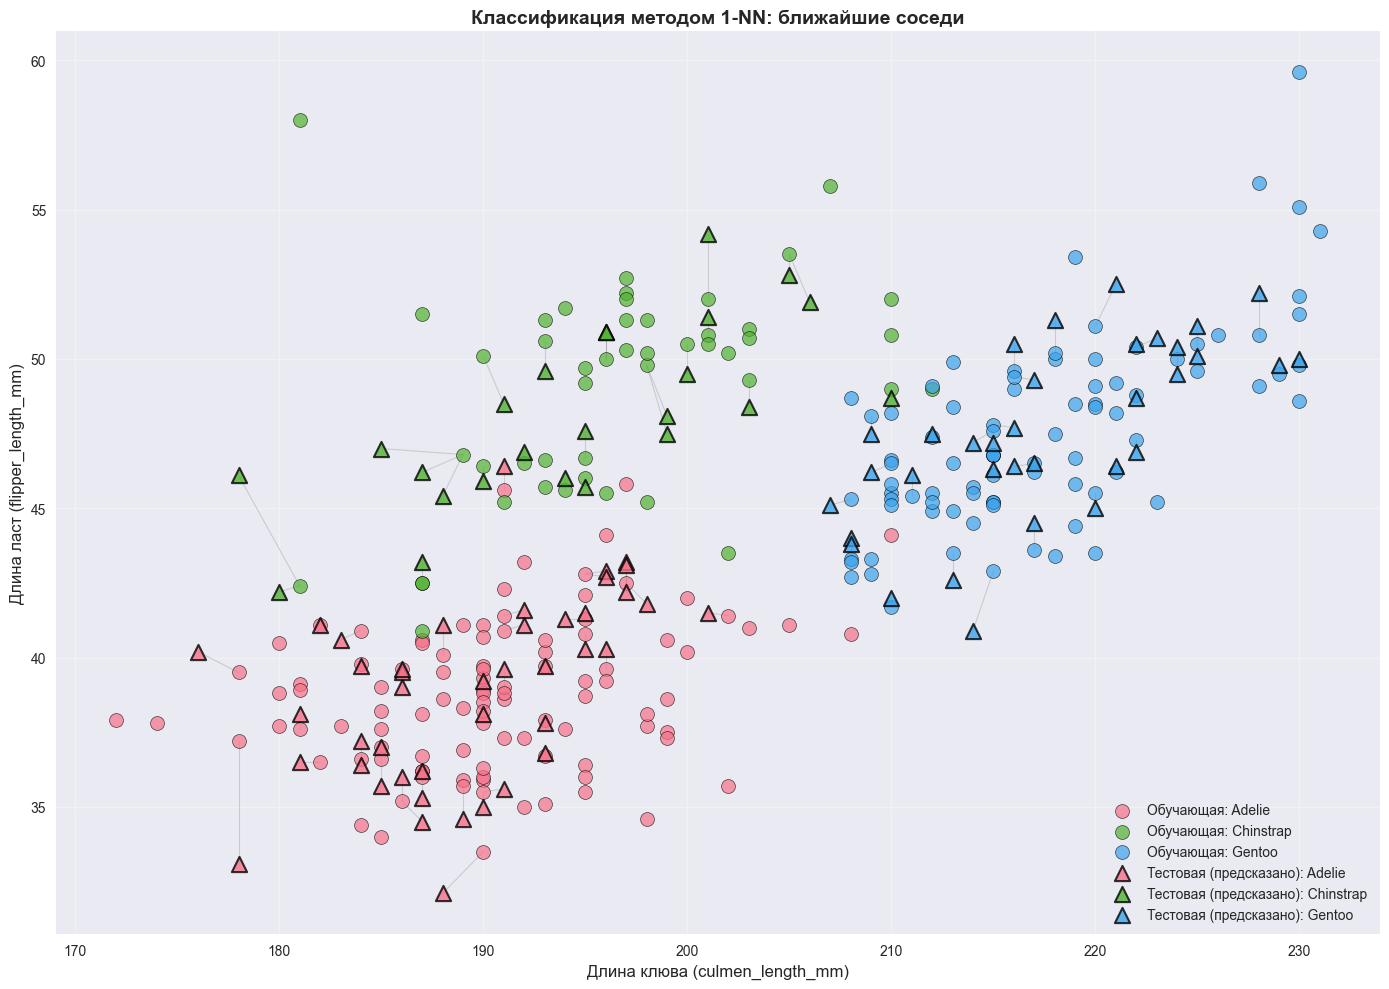

In [24]:
plt.figure(figsize=(14, 10))

# Получаем уникальные классы для цветовой схемы
unique_classes = np.unique(y_train_2d_array)
colors = sns.color_palette("husl", len(unique_classes))
class_color_map = dict(zip(unique_classes, colors))

# Визуализация обучающей выборки (цветные точки по реальным классам)
for species in unique_classes:
    mask = y_train_2d_array == species
    plt.scatter(
        X_train_2d_array[mask, 0], 
        X_train_2d_array[mask, 1],
        c=[class_color_map[species]], 
        label=f"Обучающая: {species}",
        alpha=0.7,
        s=100,
        edgecolors="black",
        linewidth=0.5,
        zorder=3
    )

# Визуализация тестовой выборки (точки окрашены по предсказанным классам)
for species in unique_classes:
    mask = predictions == species
    if np.any(mask):
        plt.scatter(
            X_test_2d_array[mask, 0], 
            X_test_2d_array[mask, 1],
            c=[class_color_map[species]], 
            label=f"Тестовая (предсказано): {species}",
            alpha=0.8,
            s=120,
            marker="^",
            edgecolors="black",
            linewidth=1.5,
            zorder=4
        )

# Проводим линии от тестовых точек к их ближайшим соседям
for i, test_point in enumerate(X_test_2d_array):
    nearest_idx = nearest_neighbors_indices[i]
    nearest_point = X_train_2d_array[nearest_idx]
    
    plt.plot(
        [test_point[0], nearest_point[0]], 
        [test_point[1], nearest_point[1]], 
        "gray", 
        alpha=0.3, 
        linewidth=0.8,
        zorder=1
    )

plt.xlabel("Длина клюва (culmen_length_mm)", fontsize=12)
plt.ylabel("Длина ласт (flipper_length_mm)", fontsize=12)
plt.title("Классификация методом 1-NN: ближайшие соседи", fontsize=14, fontweight="bold")
plt.legend(loc="best", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Сравнение с sklearn


In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Создаем классификатор k-NN с k=1
knn_classifier = KNeighborsClassifier(n_neighbors=1, metric="euclidean")

# Обучаем на обучающей выборке
knn_classifier.fit(X_train_2d_array, y_train_2d_array)

# Предсказываем классы для тестовой выборки
sklearn_predictions = knn_classifier.predict(X_test_2d_array)

# Вычисляем точность
sklearn_accuracy = accuracy_score(y_test_2d_array, sklearn_predictions)

print(f"Точность нашей реализации: {accuracy:.2%}")
print(f"Точность sklearn: {sklearn_accuracy:.2%}")
print(f"\nРазница: {abs(accuracy - sklearn_accuracy):.4f}")

# Проверяем, что предсказания совпадают
predictions_match = np.array_equal(predictions, sklearn_predictions)
print(f"\nПредсказания совпадают: {predictions_match}")

if predictions_match:
    print("✓ Наша реализация полностью совпадает с sklearn!")
else:
    print("⚠ Предсказания различаются. Проверь реализацию.")

Точность нашей реализации: 95.05%
Точность sklearn: 95.05%

Разница: 0.0000

Предсказания совпадают: True
✓ Наша реализация полностью совпадает с sklearn!


## Задание 4. Больше соседей

В предыдущем задании ты использовал алгоритм 1-NN (k=1), где для классификации 
использовался только один ближайший сосед. Теперь ты изучишь, как изменение 
количества соседей влияет на качество классификации. Это важный шаг в 
понимании того, как параметр k влияет на переобучение и недообучение модели.

1. **Исследование влияния количества соседей:**
   - Используй `KNeighborsClassifier` из `sklearn.neighbors` для классификации.
   - Проверь количество соседей от 1 до 30 включительно (k от 1 до 30).
   - Для каждого значения k обучи классификатор на обучающей выборке и 
   вычисли точность на обучающей и тестовой выборках.
   - Сохрани результаты в два списка: один для точности на обучающей выборке, 
   другой для точности на тестовой выборке.

2. **Визуализация зависимости точности от количества соседей:**
   - Построй график, на котором по оси X отложено количество соседей (k), а 
   по оси Y — точность классификации.
   - На графике должны быть две линии:
     - Линия для точности на обучающей выборке (train accuracy).
     - Линия для точности на тестовой выборке (test accuracy).
   - Используй разные цвета и маркеры для каждой линии.
   - Добавь подписи осей, заголовок графика и легенду.
   - Добавь сетку для удобства чтения значений.

### 1. Исследование влияния количества соседей


In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Диапазон значений k (количество соседей) от 1 до 10
k_values = range(1, 30)

# Списки для хранения точности на обучающей и тестовой выборках
train_accuracies = []
test_accuracies = []

# Для каждого значения k обучаем классификатор и вычисляем точность
for k in k_values:
    # Создаем классификатор с текущим значением k
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    
    # Обучаем на обучающей выборке
    knn.fit(X_train_2d_array, y_train_2d_array)
    
    # Вычисляем точность на обучающей выборке
    train_pred = knn.predict(X_train_2d_array)
    train_acc = accuracy_score(y_train_2d_array, train_pred)
    train_accuracies.append(train_acc)
    
    # Вычисляем точность на тестовой выборке
    test_pred = knn.predict(X_test_2d_array)
    test_acc = accuracy_score(y_test_2d_array, test_pred)
    test_accuracies.append(test_acc)

### 2. Визуализация зависимости точности от количества соседей


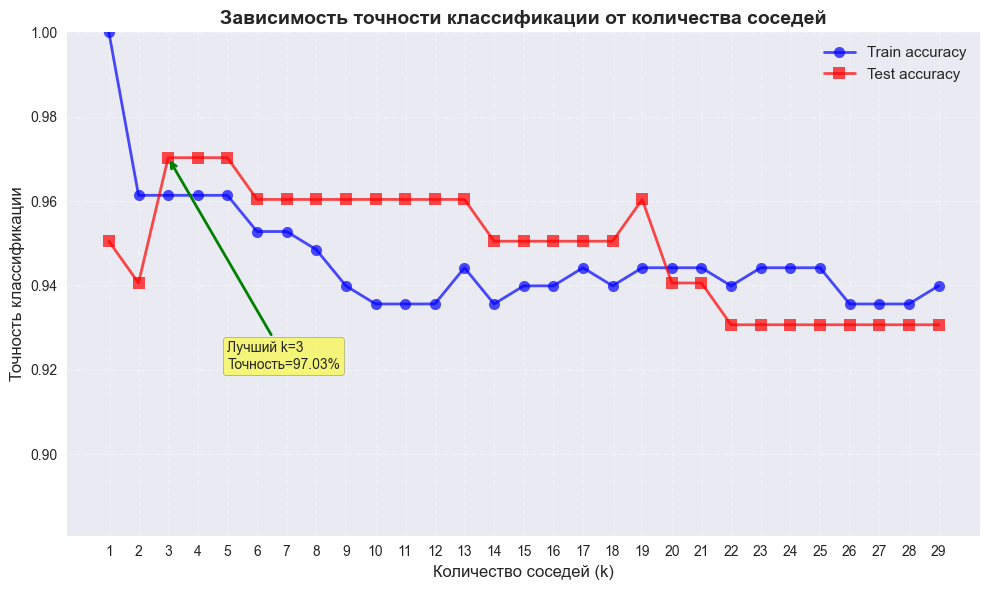

In [27]:
# Построение графика зависимости точности от количества соседей
plt.figure(figsize=(10, 6))

# Преобразуем k_values в список для удобства
k_list = list(k_values)

# Построение линий для обучающей и тестовой выборок
plt.plot(k_list, train_accuracies, marker="o", linewidth=2, markersize=8, 
         label="Train accuracy", color="blue", alpha=0.7)
plt.plot(k_list, test_accuracies, marker="s", linewidth=2, markersize=8, 
         label="Test accuracy", color="red", alpha=0.7)

# Настройка графика
plt.xlabel("Количество соседей (k)", fontsize=12)
plt.ylabel("Точность классификации", fontsize=12)
plt.title("Зависимость точности классификации от количества соседей", 
          fontsize=14, fontweight="bold")
plt.legend(loc="best", fontsize=11)
plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(k_list)
plt.ylim([min(min(train_accuracies), min(test_accuracies)) - 0.05, 1.0])

# Добавляем аннотации для лучших значений
best_test_k = k_list[np.argmax(test_accuracies)]
best_test_acc = max(test_accuracies)
plt.annotate(f"Лучший k={best_test_k}\nТочность={best_test_acc:.2%}", 
             xy=(best_test_k, best_test_acc), 
             xytext=(best_test_k + 2, best_test_acc - 0.05),
             arrowprops=dict(arrowstyle="->", color="green", lw=2),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))

plt.tight_layout()
plt.show()


## Задание 5. Стандартизация признаков

В предыдущих заданиях ты работал с признаками, которые имели схожие масштабы 
(длина клюва и длина ласт измеряются в миллиметрах). Однако в реальных задачах 
признаки часто имеют разные единицы измерения и масштабы. Например, масса тела 
пингвина измеряется в граммах (значения порядка тысяч), а длина клюва — в 
миллиметрах (значения порядка десятков).

Когда признаки имеют разные масштабы, метрики расстояния (например, евклидова 
метрика) будут в основном определяться признаком с большими значениями. Это 
может привести к тому, что важные закономерности в признаках с меньшими 
значениями будут проигнорированы, что негативно скажется на качестве 
классификации.

**Стандартизация** — это процесс преобразования признаков таким образом, чтобы 
они имели нулевое среднее значение и единичную дисперсию. Это позволяет всем 
признакам вносить равный вклад в вычисление расстояний, независимо от их 
исходных масштабов.
![Стандартизация](../../production/AI_Machine_Learning.Project_2.ID_1577772/misc/images/standardization.png)

1. **Работа с признаками разного масштаба:**
   - Используй признаки `body_mass_g` (масса тела) и `culmen_length_mm` 
   (длина клюва) для классификации.
   - Обучи модель k-NN на этих признаках с параметром k=3.
   - Вычисли точность классификации на тестовой выборке.
   - Визуализируй данные в пространстве этих признаков: построй график 
   рассеяния с обучающей и тестовой выборками, где точки окрашены по классам.

2. **Анализ проблемы масштабов:**
   - Выведи статистику по признакам (среднее, стандартное отклонение, минимум, 
   максимум) для обучающей выборки.
   - Объясни, почему признаки с разными масштабами могут создавать проблемы 
   для метрических алгоритмов.

3. **Применение стандартизации:**
   - Используй `StandardScaler` из `sklearn.preprocessing` для стандартизации 
   признаков.
   - Примени `fit_transform` к обучающей выборке и `transform` к тестовой 
   выборке (важно: стандартизация должна быть обучена только на обучающих 
   данных!).
   - Выведи среднее значение и дисперсию стандартизированных признаков для 
   обучающей выборки.
   - Убедись, что среднее значение близко к 0, а дисперсия близка к 1 для 
   каждого признака.

4. **Переобучение модели на стандартизированных данных:**
   - Обучи модель k-NN на стандартизированных признаках с параметром k=3.
   - Вычисли точность классификации на тестовой выборке.
   - Сравни точность до и после стандартизации.
   - Визуализируй стандартизированные данные: построй график рассеяния с 
   обучающей и тестовой выборками.

5. **Сравнение результатов:**
   - Сравни визуально графики до и после стандартизации: как изменилось 
   распределение точек в пространстве признаков?


### 1. Работа с признаками разного масштаба


Точность классификации на признаках разного масштаба: 73.81%


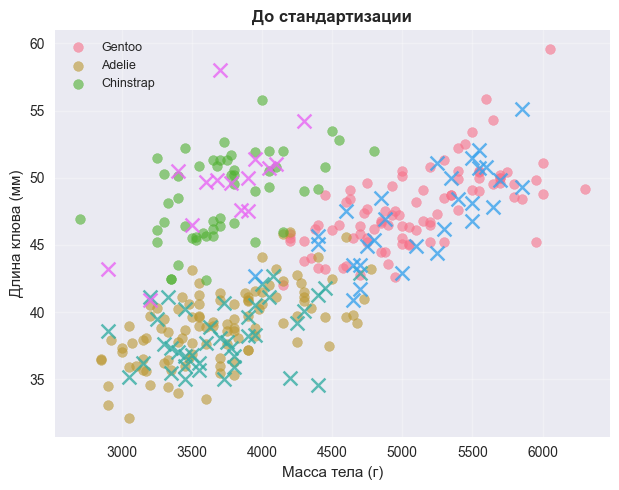

In [28]:
# Используем признаки с разными масштабами: масса тела и длина клюва
# Используем исходные данные X и y для создания новых выборок
X_different_scale = X[['body_mass_g', 'culmen_length_mm']]
X_train_different_scale, X_test_different_scale, y_train_different_scale, y_test_different_scale = train_test_split(
    X_different_scale, y, test_size=0.25, random_state=42
)
X_train_different_scale = X_train_different_scale.values
X_test_different_scale = X_test_different_scale.values

# Обучаем модель k-NN с параметром k=3
knn_different_scale = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn_different_scale.fit(X_train_different_scale, y_train_different_scale)

# Вычисляем точность на тестовой выборке
test_pred_different_scale = knn_different_scale.predict(X_test_different_scale)
test_accuracy_different_scale = accuracy_score(y_test_different_scale, test_pred_different_scale)

print(f"Точность классификации на признаках разного масштаба: {test_accuracy_different_scale:.2%}")

# Визуализация данных в пространстве этих признаков
plt.figure(figsize=(12, 5))

# График для обучающей выборки
plt.subplot(1, 2, 1)
for species in y_train_different_scale.unique():
    mask = y_train_different_scale == species
    plt.scatter(X_train_different_scale[mask, 0], X_train_different_scale[mask, 1], 
               label=species, alpha=0.6, s=50)

# График для тестовой выборки
for species in y_test_different_scale.unique():
    mask = y_test_different_scale == species
    plt.scatter(X_test_different_scale[mask, 0], X_test_different_scale[mask, 1], 
               marker='x', s=100, alpha=0.8)

plt.xlabel('Масса тела (г)', fontsize=11)
plt.ylabel('Длина клюва (мм)', fontsize=11)
plt.title('До стандартизации', fontsize=12, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 2. Анализ проблемы масштабов


In [29]:
# Статистика по признакам для обучающей выборки
print("Статистика по признакам (обучающая выборка):")
print("=" * 60)
stats_df = pd.DataFrame({
    'body_mass_g': X_train_different_scale[:, 0],
    'culmen_length_mm': X_train_different_scale[:, 1]
})
print(stats_df.describe())
print("\n" + "=" * 60)
print("\nПроблема: признаки имеют разные масштабы!")
print(f"Масса тела: среднее = {stats_df['body_mass_g'].mean():.2f}, "
      f"стандартное отклонение = {stats_df['body_mass_g'].std():.2f}")
print(f"Длина клюва: среднее = {stats_df['culmen_length_mm'].mean():.2f}, "
      f"стандартное отклонение = {stats_df['culmen_length_mm'].std():.2f}")
print("\nПри вычислении евклидова расстояния признак с большими значениями (масса тела)")
print("будет доминировать, что может привести к потере важной информации о длине клюва.")


Статистика по признакам (обучающая выборка):
       body_mass_g  culmen_length_mm
count   250.000000        250.000000
mean   4212.400000         44.224000
std     810.090257          5.341606
min    2700.000000         32.100000
25%    3550.000000         39.625000
50%    4050.000000         45.200000
75%    4800.000000         48.700000
max    6300.000000         59.600000


Проблема: признаки имеют разные масштабы!
Масса тела: среднее = 4212.40, стандартное отклонение = 810.09
Длина клюва: среднее = 44.22, стандартное отклонение = 5.34

При вычислении евклидова расстояния признак с большими значениями (масса тела)
будет доминировать, что может привести к потере важной информации о длине клюва.


### 3. Применение стандартизации


In [30]:
from sklearn.preprocessing import StandardScaler

# Создаем объект StandardScaler
scaler = StandardScaler()

# Обучаем стандартизацию ТОЛЬКО на обучающей выборке
X_train_scaled = scaler.fit_transform(X_train_different_scale)

# Применяем стандартизацию к тестовой выборке (используем параметры из обучающей)
X_test_scaled = scaler.transform(X_test_different_scale)

# Выводим среднее значение и дисперсию стандартизированных признаков
print("Статистика стандартизированных признаков (обучающая выборка):")
print("=" * 60)
scaled_stats = pd.DataFrame(X_train_scaled, columns=['body_mass_g', 'culmen_length_mm'])
print(f"Среднее значение body_mass_g: {scaled_stats['body_mass_g'].mean():.6f}")
print(f"Дисперсия body_mass_g: {scaled_stats['body_mass_g'].var():.6f}")
print(f"\nСреднее значение culmen_length_mm: {scaled_stats['culmen_length_mm'].mean():.6f}")
print(f"Дисперсия culmen_length_mm: {scaled_stats['culmen_length_mm'].var():.6f}")
print("\n" + "=" * 60)
print("\n✓ Среднее значение близко к 0, дисперсия близка к 1 для каждого признака!")


Статистика стандартизированных признаков (обучающая выборка):
Среднее значение body_mass_g: 0.000000
Дисперсия body_mass_g: 1.004016

Среднее значение culmen_length_mm: 0.000000
Дисперсия culmen_length_mm: 1.004016


✓ Среднее значение близко к 0, дисперсия близка к 1 для каждого признака!


### 4. Переобучение модели на стандартизированных данных


Точность классификации на стандартизированных признаках: 94.05%


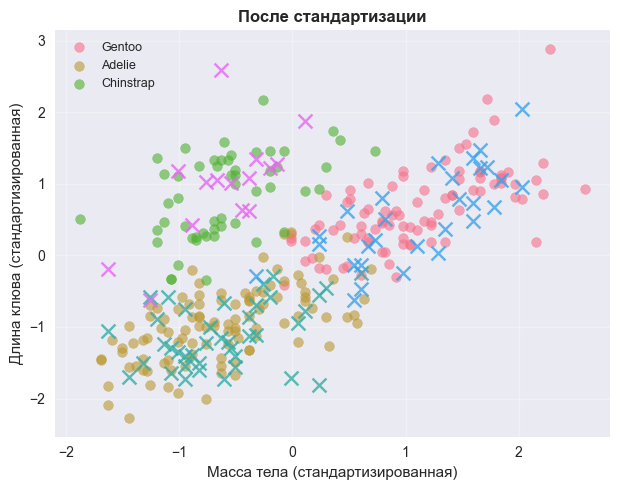

In [31]:
# Обучаем модель k-NN на стандартизированных признаках
knn_scaled = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn_scaled.fit(X_train_scaled, y_train_different_scale)

# Вычисляем точность классификации на тестовой выборке
test_pred_scaled = knn_scaled.predict(X_test_scaled)
test_accuracy_scaled = accuracy_score(y_test_different_scale, test_pred_scaled)

print(f"Точность классификации на стандартизированных признаках: {test_accuracy_scaled:.2%}")

# Визуализация стандартизированных данных
plt.figure(figsize=(12, 5))

# График для обучающей выборки
plt.subplot(1, 2, 1)
for species in y_train_different_scale.unique():
    mask = y_train_different_scale == species
    plt.scatter(X_train_scaled[mask, 0], X_train_scaled[mask, 1], 
               label=species, alpha=0.6, s=50)

# График для тестовой выборки
for species in y_test_different_scale.unique():
    mask = y_test_different_scale == species
    plt.scatter(X_test_scaled[mask, 0], X_test_scaled[mask, 1], 
               marker='x', s=100, alpha=0.8)

plt.xlabel('Масса тела (стандартизированная)', fontsize=11)
plt.ylabel('Длина клюва (стандартизированная)', fontsize=11)
plt.title('После стандартизации', fontsize=12, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 5. Сравнение результатов


In [32]:
# Сравнение результатов
print("=" * 60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)
print(f"\nТочность ДО стандартизации: {test_accuracy_different_scale:.2%}")
print(f"Точность ПОСЛЕ стандартизации: {test_accuracy_scaled:.2%}")
print(f"\nИзменение точности: {test_accuracy_scaled - test_accuracy_different_scale:+.2%}")

if test_accuracy_scaled > test_accuracy_different_scale:
    print("\n✓ Стандартизация улучшила качество классификации!")
    print("\nОбъяснение:")
    print("После стандартизации все признаки имеют одинаковый масштаб (среднее ≈ 0, дисперсия ≈ 1).")
    print("Это позволяет метрике расстояния учитывать вклад всех признаков равномерно,")
    print("а не только признака с большими значениями (масса тела).")
elif test_accuracy_scaled < test_accuracy_different_scale:
    print("\n⚠ Стандартизация немного снизила точность.")
    print("Это может происходить, если один из признаков действительно более важен для классификации.")
else:
    print("\n→ Точность не изменилась.")

print("\n" + "=" * 60)
print("\nВизуальное сравнение:")
print("На графике 'После стандартизации' видно, что распределение точек изменилось:")
print("- Признаки теперь имеют одинаковый масштаб")
print("- Расстояния между точками вычисляются более корректно")
print("- Все признаки вносят равный вклад в классификацию")


СРАВНЕНИЕ РЕЗУЛЬТАТОВ

Точность ДО стандартизации: 73.81%
Точность ПОСЛЕ стандартизации: 94.05%

Изменение точности: +20.24%

✓ Стандартизация улучшила качество классификации!

Объяснение:
После стандартизации все признаки имеют одинаковый масштаб (среднее ≈ 0, дисперсия ≈ 1).
Это позволяет метрике расстояния учитывать вклад всех признаков равномерно,
а не только признака с большими значениями (масса тела).


Визуальное сравнение:
На графике 'После стандартизации' видно, что распределение точек изменилось:
- Признаки теперь имеют одинаковый масштаб
- Расстояния между точками вычисляются более корректно
- Все признаки вносят равный вклад в классификацию


## Задание 6. Кросс-валидация

В предыдущих заданиях ты использовал фиксированное разделение данных на 
обучающую и тестовую выборки. Однако такой подход имеет ограничения: результат 
может сильно зависеть от того, как именно были разделены данные. Кроме того, 
при подборе гиперпараметров (таких как количество соседей k в алгоритме k-NN) 
использование тестовой выборки для оценки качества может привести к 
переобучению на тестовых данных.

**Гиперпараметр** — это параметр алгоритма, который задаётся до начала обучения 
и не изменяется в процессе обучения. В алгоритме k-NN гиперпараметром является 
количество соседей k. Правильный выбор гиперпараметра критически важен для 
качества модели: слишком маленькое k может привести к переобучению (модель 
запоминает шум в данных), а слишком большое — к недообучению (модель становится 
слишком простой и не учитывает локальные закономерности).

**K-fold кросс-валидация** — это метод оценки качества модели, при котором 
данные разбиваются на k частей (фолдов). Модель обучается k раз: каждый раз 
одна из частей используется как валидационная выборка, а остальные k-1 частей — 
как обучающая. В результате получается k оценок качества, которые можно 
усреднить для получения более надёжной оценки.

![K-Fold](../../production/AI_Machine_Learning.Project_2.ID_1577772/misc/images/k_fold.png)


1. **Реализация k-fold кросс-валидации:**
   - Используй `cross_val_score` из `sklearn.model_selection` для проведения 
   кросс-валидации.
   - Проверь значения k от 1 до 30 включительно.
   - Используй 5-fold кросс-валидацию (cv=5).
   - Для каждого значения k вычисли среднюю точность и стандартное отклонение 
   по всем фолдам.

2. **Визуализация результатов кросс-валидации:**
   - Построй график, на котором по оси X отложено количество соседей (k), а по 
   оси Y — средняя точность классификации.
   - Добавь на график область, показывающую стандартное отклонение используй `fill_between`.
   - Добавь подписи осей, заголовок графика и легенду.
   - Добавь сетку для удобства чтения значений.

3. **Выбор оптимального гиперпараметра:**
   - Определи оптимальное значение k на основе результатов кросс-валидации 
   (значение с максимальной средней точностью).
   - Выведи оптимальное значение k и соответствующую ему среднюю точность.
   - Объясни, почему выбранное значение k является оптимальным.


### 2. Реализация k-fold кросс-валидации


In [33]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Используем все признаки (не только 2D) для кросс-валидации
# Используем очищенные данные
X_all = X[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']].values
y_all = y.values

# Диапазон значений k от 1 до 30
k_values = range(1, 31)

# Списки для хранения результатов кросс-валидации
mean_scores = []
std_scores = []

print("Проведение 5-fold кросс-валидации для k от 1 до 30...")
print("=" * 70)

# Для каждого значения k проводим кросс-валидацию
for k in k_values:
    # Создаем классификатор с текущим значением k
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    
    # Проводим 5-fold кросс-валидацию
    cv_scores = cross_val_score(knn, X_all, y_all, cv=5, scoring="accuracy")
    
    # Вычисляем среднюю точность и стандартное отклонение
    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)
    
    mean_scores.append(mean_score)
    std_scores.append(std_score)
    
    # Выводим результаты для первых 5 и последних 5 значений k
    if k <= 5 or k >= 26:
        print(f"k={k:2d}: Средняя точность = {mean_score:.4f} ({mean_score:.2%}), "
              f"Стд. отклонение = {std_score:.4f}")

print("=" * 70)
print("Кросс-валидация завершена!")


Проведение 5-fold кросс-валидации для k от 1 до 30...
k= 1: Средняя точность = 0.8505 (85.05%), Стд. отклонение = 0.0496
k= 2: Средняя точность = 0.7997 (79.97%), Стд. отклонение = 0.0660
k= 3: Средняя точность = 0.7908 (79.08%), Стд. отклонение = 0.0628
k= 4: Средняя точность = 0.8117 (81.17%), Стд. отклонение = 0.0526
k= 5: Средняя точность = 0.8027 (80.27%), Стд. отклонение = 0.0631
k=26: Средняя точность = 0.7336 (73.36%), Стд. отклонение = 0.0206
k=27: Средняя точность = 0.7427 (74.27%), Стд. отклонение = 0.0245
k=28: Средняя точность = 0.7277 (72.77%), Стд. отклонение = 0.0320
k=29: Средняя точность = 0.7337 (73.37%), Стд. отклонение = 0.0277
k=30: Средняя точность = 0.7396 (73.96%), Стд. отклонение = 0.0213
Кросс-валидация завершена!


### 3. Визуализация результатов кросс-валидации


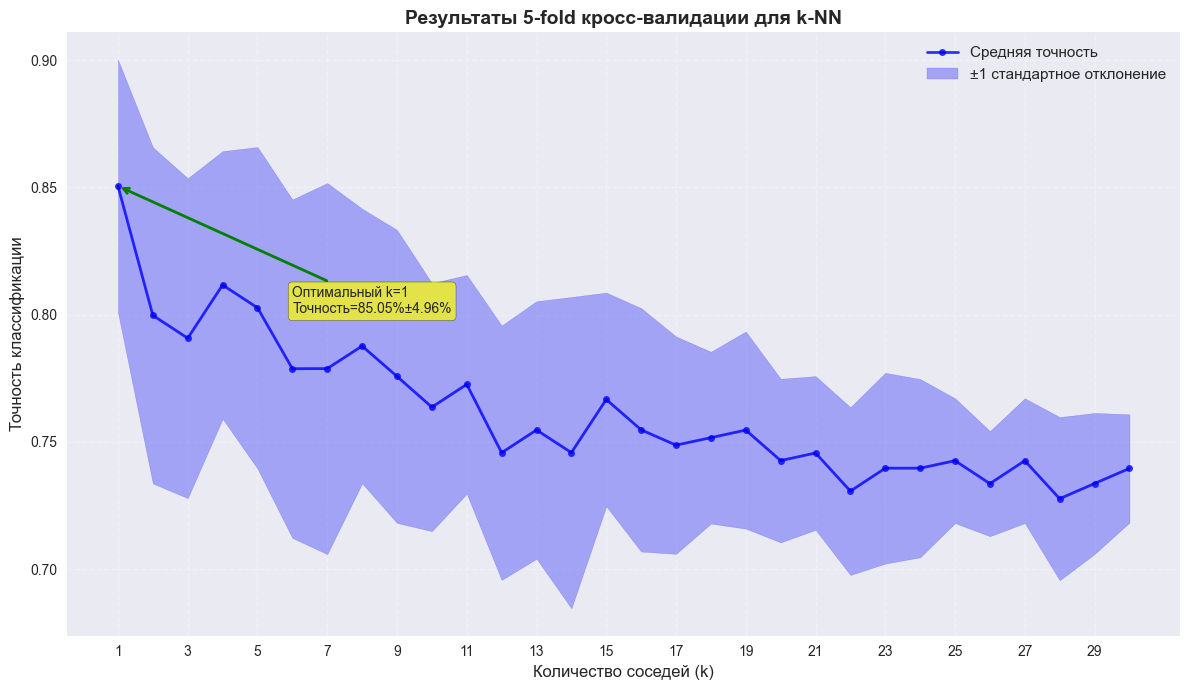

In [34]:
# Построение графика результатов кросс-валидации
plt.figure(figsize=(12, 7))

# Преобразуем k_values в список для удобства
k_list = list(k_values)

# Построение линии средней точности
plt.plot(k_list, mean_scores, marker="o", linewidth=2, markersize=5, 
         label="Средняя точность", color="blue", alpha=0.8)

# Добавление области стандартного отклонения
plt.fill_between(k_list, 
                 np.array(mean_scores) - np.array(std_scores),
                 np.array(mean_scores) + np.array(std_scores),
                 alpha=0.3, color="blue", label="±1 стандартное отклонение")

# Настройка графика
plt.xlabel("Количество соседей (k)", fontsize=12)
plt.ylabel("Точность классификации", fontsize=12)
plt.title("Результаты 5-fold кросс-валидации для k-NN", 
          fontsize=14, fontweight="bold")
plt.legend(loc="best", fontsize=11)
plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(range(1, 31, 2))  # Показываем каждое второе значение для читаемости

# Добавляем аннотацию для оптимального значения
best_k_idx = np.argmax(mean_scores)
best_k = k_list[best_k_idx]
best_mean_score = mean_scores[best_k_idx]
best_std_score = std_scores[best_k_idx]

plt.annotate(f"Оптимальный k={best_k}\nТочность={best_mean_score:.2%}±{best_std_score:.2%}", 
             xy=(best_k, best_mean_score), 
             xytext=(best_k + 5, best_mean_score - 0.05),
             arrowprops=dict(arrowstyle="->", color="green", lw=2),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.show()


### 4. Выбор оптимального гиперпараметра


In [35]:
# Определение оптимального значения k
best_k_idx = np.argmax(mean_scores)
best_k = k_list[best_k_idx]
best_mean_score = mean_scores[best_k_idx]
best_std_score = std_scores[best_k_idx]

print("=" * 70)
print("ВЫБОР ОПТИМАЛЬНОГО ГИПЕРПАРАМЕТРА")
print("=" * 70)
print(f"\nОптимальное количество соседей (k): {best_k}")
print(f"Средняя точность при k={best_k}: {best_mean_score:.4f} ({best_mean_score:.2%})")
print(f"Стандартное отклонение при k={best_k}: {best_std_score:.4f} ({best_std_score:.2%})")

# Находим топ-5 значений k
top_5_indices = np.argsort(mean_scores)[-5:][::-1]
print("\n" + "=" * 70)
print("ТОП-5 значений k по средней точности:")
print("=" * 70)
for i, idx in enumerate(top_5_indices, 1):
    k_val = k_list[idx]
    mean_val = mean_scores[idx]
    std_val = std_scores[idx]
    print(f"{i}. k={k_val:2d}: {mean_val:.4f} ({mean_val:.2%}) ± {std_val:.4f}")

print("\n" + "=" * 70)
print("ОБЪЯСНЕНИЕ ВЫБОРА ОПТИМАЛЬНОГО k")
print("=" * 70)
print(f"\nВыбранное значение k={best_k} является оптимальным по следующим причинам:")
print(f"1. Максимальная средняя точность: {best_mean_score:.2%}")
print(f"2. Стабильность результатов: стандартное отклонение {best_std_score:.4f} показывает,")
print(f"   что модель дает стабильные результаты на разных фолдах кросс-валидации.")
print(f"3. Баланс между точностью и обобщением: значение k={best_k} не слишком мало")
print(f"   (что могло бы привести к переобучению) и не слишком велико")
print(f"   (что могло бы привести к недообучению).")
print(f"\nКросс-валидация позволяет получить более надёжную оценку качества модели,")
print(f"чем простое разделение на train/test, так как использует все данные")
print(f"и для обучения, и для валидации, что уменьшает зависимость от конкретного")
print(f"разделения данных.")


ВЫБОР ОПТИМАЛЬНОГО ГИПЕРПАРАМЕТРА

Оптимальное количество соседей (k): 1
Средняя точность при k=1: 0.8505 (85.05%)
Стандартное отклонение при k=1: 0.0496 (4.96%)

ТОП-5 значений k по средней точности:
1. k= 1: 0.8505 (85.05%) ± 0.0496
2. k= 4: 0.8117 (81.17%) ± 0.0526
3. k= 5: 0.8027 (80.27%) ± 0.0631
4. k= 2: 0.7997 (79.97%) ± 0.0660
5. k= 3: 0.7908 (79.08%) ± 0.0628

ОБЪЯСНЕНИЕ ВЫБОРА ОПТИМАЛЬНОГО k

Выбранное значение k=1 является оптимальным по следующим причинам:
1. Максимальная средняя точность: 85.05%
2. Стабильность результатов: стандартное отклонение 0.0496 показывает,
   что модель дает стабильные результаты на разных фолдах кросс-валидации.
3. Баланс между точностью и обобщением: значение k=1 не слишком мало
   (что могло бы привести к переобучению) и не слишком велико
   (что могло бы привести к недообучению).

Кросс-валидация позволяет получить более надёжную оценку качества модели,
чем простое разделение на train/test, так как использует все данные
и для обучения, и для в

## Глава V: Проблемы K-NN и проклятье размерности

Метрические алгоритмы, такие как k-NN, имеют множество преимуществ: они просты 
в понимании и реализации, не требуют явного обучения модели, хорошо работают 
с нелинейными зависимостями и легко адаптируются к новым данным. Однако у них 
есть и существенные ограничения.

Одной из главных проблем метрических алгоритмов является **проклятье 
размерности** (curse of dimensionality). С увеличением количества признаков 
объем пространства признаков растет экспоненциально, и данные становятся 
все более разреженными. В результате расстояния между точками становятся 
похожими друг на друга, что делает метрики расстояния менее информативными 
для классификации.


### Задание 2.1: Генерация выборки


In [36]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Диапазон количества признаков: от 2 до 50 с шагом 2
n_features_range = range(1, 300, 10)

# Списки для хранения результатов
dimensions = []
accuracies = []

print("Генерация датасетов и обучение моделей...")
print("=" * 70)

# Для каждого количества признаков
for n_features in n_features_range:
    # Генерация синтетического датасета
    X, y = make_classification(
        n_samples=10000,
        n_features=n_features,
        n_classes=2,
        n_informative=3,  # Все признаки информативны
        n_redundant=>0,
        n_clusters_per_class=1,
        random_state=42
    )
    
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.25, 
        random_state=42
    )
    
    # Обучение модели k-NN
    knn = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
    knn.fit(X_train, y_train)
    
    # Вычисление точности на тестовой выборке
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    dimensions.append(n_features)
    accuracies.append(accuracy)
    
    # Выводим результаты для некоторых размерностей
    if n_features <= 10 or n_features >= 40 or n_features % 10 == 0:
        print(f"Размерность: {n_features:2d} признаков, Точность: {accuracy:.4f} ({accuracy:.2%})")

print("=" * 70)
print("Генерация и обучение завершены!")


SyntaxError: invalid syntax (176281417.py, line 24)

### Задание 2.2: Проклятье размерности


In [ ]:
# Визуализация зависимости точности от размерности
plt.figure(figsize=(12, 7))

plt.plot(dimensions, accuracies, marker="o", linewidth=2, markersize=6, 
         color="blue", alpha=0.7)

# Находим размерность с максимальной точностью
best_dim_idx = np.argmax(accuracies)
best_dim = dimensions[best_dim_idx]
best_acc = accuracies[best_dim_idx]

# Добавляем аннотацию для максимальной точности
plt.annotate(f"Максимум: {best_dim} признаков\nТочность: {best_acc:.2%}", 
             xy=(best_dim, best_acc), 
             xytext=(best_dim + 5, best_acc + 0.05),
             arrowprops=dict(arrowstyle="->", color="green", lw=2),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.xlabel("Количество признаков (размерность)", fontsize=12)
plt.ylabel("Точность классификации", fontsize=12)
plt.title("Зависимость точности классификации от размерности признаков\n(Проклятье размерности)", 
          fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


In [ ]:
# Анализ результатов
print("=" * 70)
print("АНАЛИЗ РЕЗУЛЬТАТОВ: ПРОКЛЯТЬЕ РАЗМЕРНОСТИ")
print("=" * 70)

print(f"\nРазмерность с максимальной точностью: {best_dim} признаков")
print(f"Максимальная точность: {best_acc:.4f} ({best_acc:.2%})")

# Анализ тренда
print("\n" + "=" * 70)
print("АНАЛИЗ ТРЕНДА:")
print("=" * 70)

# Находим, где начинается падение точности
max_acc_idx = best_dim_idx
if max_acc_idx < len(accuracies) - 1:
    print(f"\n1. Точность максимальна при {best_dim} признаках.")
    print(f"2. После этого точность начинает снижаться.")
    print(f"3. При 50 признаках точность составляет {accuracies[-1]:.4f} ({accuracies[-1]:.2%})")
    print(f"   (снижение на {best_acc - accuracies[-1]:.4f} по сравнению с максимумом)")

print("\n" + "=" * 70)
print("ОБЪЯСНЕНИЕ ПРОКЛЯТЬЯ РАЗМЕРНОСТИ:")
print("=" * 70)
print("\n1. Почему точность сначала растет:")
print("   - Больше признаков может содержать больше полезной информации")
print("   - Модель получает больше данных для принятия решений")
print("   - При небольшой размерности данные не слишком разрежены")

print("\n2. Почему точность затем падает (проклятье размерности):")
print("   - С ростом размерности объем пространства растет экспоненциально")
print("   - Данные становятся все более разреженными")
print("   - Расстояния между точками становятся похожими друг на друга")
print("   - Метрики расстояния теряют информативность для классификации")

print("\n3. Почему расстояния становятся похожими при высокой размерности:")
print("   - В высокоразмерном пространстве все точки находятся примерно на")
print("     одинаковом расстоянии от центра распределения")
print("   - Дисперсия расстояний между точками уменьшается")
print("   - Это делает k-NN менее эффективным, так как он основан на расстояниях")

print("\n4. Проклятье размерности в метрических алгоритмах:")
print("   - Метрические алгоритмы (k-NN) особенно чувствительны к высокой размерности")
print("   - Они полностью зависят от метрик расстояния")
print("   - Когда расстояния теряют информативность, качество классификации падает")


### Задание 2.3: Уменьшение размерности


In [ ]:
from sklearn.decomposition import PCA

# Генерируем датасет с максимальным количеством признаков (50)
X_full, y_full = make_classification(
    n_samples=1000,
    n_features=50,
    n_classes=2,
    n_informative=50,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Разделение на обучающую и тестовую выборки
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, 
    test_size=0.25, 
    random_state=42
)

# Базовое значение точности без PCA
knn_baseline = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_baseline.fit(X_train_full, y_train_full)
y_pred_baseline = knn_baseline.predict(X_test_full)
baseline_accuracy = accuracy_score(y_test_full, y_pred_baseline)

print(f"Точность без PCA (50 признаков): {baseline_accuracy:.4f} ({baseline_accuracy:.2%})")
print("\nПрименение PCA...")
print("=" * 70)


In [ ]:
# Диапазон количества главных компонент: от 2 до 50 с шагом 2
n_components_range = range(2, 51, 2)

# Списки для хранения результатов PCA
pca_components = []
pca_accuracies = []

# Для каждого количества главных компонент
for n_components in n_components_range:
    # Создаем и обучаем PCA на обучающей выборке
    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train_full)
    
    # Применяем PCA к тестовой выборке (важно: только transform, не fit!)
    X_test_pca = pca.transform(X_test_full)
    
    # Обучение модели k-NN на преобразованных признаках
    knn_pca = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
    knn_pca.fit(X_train_pca, y_train_full)
    
    # Вычисление точности на тестовой выборке
    y_pred_pca = knn_pca.predict(X_test_pca)
    accuracy_pca = accuracy_score(y_test_full, y_pred_pca)
    
    pca_components.append(n_components)
    pca_accuracies.append(accuracy_pca)
    
    # Выводим результаты для некоторых значений
    if n_components <= 10 or n_components >= 40 or n_components % 10 == 0:
        print(f"Компонент: {n_components:2d}, Точность: {accuracy_pca:.4f} ({accuracy_pca:.2%})")

print("=" * 70)
print("PCA завершен!")


In [ ]:
# Визуализация результатов PCA
plt.figure(figsize=(12, 7))

# График для PCA
plt.plot(pca_components, pca_accuracies, marker="o", linewidth=2, markersize=6, 
         label="С PCA", color="blue", alpha=0.7)

# Горизонтальная линия для базовой точности (без PCA)
plt.axhline(y=baseline_accuracy, color="red", linestyle="--", linewidth=2, 
           label=f"Без PCA (50 признаков): {baseline_accuracy:.2%}", alpha=0.7)

# Находим оптимальное количество компонент
best_pca_idx = np.argmax(pca_accuracies)
best_pca_components = pca_components[best_pca_idx]
best_pca_acc = pca_accuracies[best_pca_idx]

# Добавляем аннотацию для оптимального значения
plt.annotate(f"Оптимум: {best_pca_components} компонент\nТочность: {best_pca_acc:.2%}", 
             xy=(best_pca_components, best_pca_acc), 
             xytext=(best_pca_components + 5, best_pca_acc + 0.05),
             arrowprops=dict(arrowstyle="->", color="green", lw=2),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.xlabel("Количество главных компонент", fontsize=12)
plt.ylabel("Точность классификации", fontsize=12)
plt.title("Зависимость точности от количества главных компонент (PCA)", 
          fontsize=14, fontweight="bold")
plt.legend(loc="best", fontsize=11)
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


In [ ]:
# Анализ результатов PCA
print("=" * 70)
print("АНАЛИЗ РЕЗУЛЬТАТОВ PCA")
print("=" * 70)

print(f"\nОптимальное количество главных компонент: {best_pca_components}")
print(f"Максимальная точность с PCA: {best_pca_acc:.4f} ({best_pca_acc:.2%})")
print(f"Точность без PCA (50 признаков): {baseline_accuracy:.4f} ({baseline_accuracy:.2%})")

improvement = best_pca_acc - baseline_accuracy
print(f"\nИзменение точности: {improvement:+.4f} ({improvement:+.2%})")

if improvement > 0:
    print("✓ PCA улучшил качество классификации!")
else:
    print("⚠ PCA не улучшил качество классификации в данном случае.")

print("\n" + "=" * 70)
print("ОБЪЯСНЕНИЕ РЕЗУЛЬТАТОВ:")
print("=" * 70)

print("\n1. Почему PCA может улучшить качество классификации:")
print("   - PCA удаляет шум и избыточную информацию из данных")
print("   - Главные компоненты сохраняют максимальную дисперсию данных")
print("   - Уменьшение размерности помогает избежать проклятья размерности")
print("   - Модель работает в более компактном и информативном пространстве")

print("\n2. Сравнение с PCA и без него:")
if best_pca_acc > baseline_accuracy:
    print("   - В данном случае PCA улучшил качество классификации")
    print("   - Это происходит потому, что PCA удалил шумовые признаки")
    print("   - И сохранил наиболее информативные направления в данных")
else:
    print("   - В данном случае PCA не улучшил качество")
    print("   - Это может происходить, если все признаки были информативными")
    print("   - Или если оптимальное количество компонент не было найдено")

print("\n3. Что такое главные компоненты:")
print("   - Главные компоненты — это новые оси в пространстве признаков")
print("   - Они направлены в сторону максимальной дисперсии данных")
print("   - Первая главная компонента объясняет наибольшую долю дисперсии")
print("   - Каждая следующая компонента объясняет оставшуюся дисперсию")

print("\n4. Связь с дисперсией данных:")
print("   - PCA находит направления, вдоль которых данные имеют максимальную дисперсию")
print("   - Эти направления наиболее информативны для классификации")
print("   - Удаляя компоненты с малой дисперсией, мы удаляем шум")
print("   - И сохраняем наиболее важную информацию для классификации")
